# Klasifikasi dan Algoritma Decision Tree C4.5

Notebook ini membahas konsep klasifikasi menggunakan algoritma **Decision Tree C4.5** (menggunakan implementasi berbasis `entropy` di scikit-learn).

### Teori Singkat C4.5:
Algoritma C4.5 merupakan pengembangan dari ID3. C4.5 memilih atribut akar berdasarkan nilai **Gain Ratio** tertinggi. Rumus utamanya meliputi:
1. **Entropy(S)** = $\sum -p_i \log_2 p_i$
2. **Information Gain(S, A)** = $Entropy(S) - \sum \frac{|S_v|}{|S|} Entropy(S_v)$
3. **Split Info(S, A)** = $-\sum \frac{|S_i|}{|S|} \log_2 \frac{|S_i|}{|S|}$
4. **Gain Ratio(S, A)** = $\frac{Gain(S, A)}{SplitInfo(S, A)}$

# Penjelasan Lengkap Algoritma C4.5

Algoritma **C4.5** adalah salah satu metode paling populer untuk membangun **Pohon Keputusan (Decision Tree)**. Jika dianalogikan, algoritma ini bekerja seperti permainan tebak-tebakan (20 Questions). C4.5 bertugas menentukan **pertanyaan terbaik mana yang harus diajukan terlebih dahulu** agar kita bisa menebak target dengan cepat dan akurat.

Berikut adalah penjelasan sederhana dari 4 rumus utama yang digunakan oleh C4.5 untuk mengambil keputusan tersebut.

---

## 1. Entropy(S) — Ukuran "Kegalauan" atau Ketidakpastian Data

$$Entropy(S) = \sum_{i=1}^{c} -p_i \log_2 p_i$$

### Apa arti rumus ini?
**Entropy** digunakan untuk mengukur seberapa acak, heterogen, atau "berantakan" data kita dalam suatu grup ($S$). 

* **$p_i$**: Probabilitas atau peluang munculnya kelas ke-$i$. Jika ada kelas "Ya" dan "Tidak", maka $p_{\text{ya}}$ adalah jumlah data "Ya" dibagi total data.

### Analogi Sederhana:
Bayangkan Anda memiliki sebuah kotak berisi kelereng:
* **Kondisi A (Sangat Rapi):** Kotak berisi **100% kelereng merah**. Tidak ada ketidakpastian sama sekali. Jika Anda mengambil satu acak, Anda pasti tahu warnanya merah. Di sini, **Entropy = 0**.
* **Kondisi B (Sangat Galau):** Kotak berisi **50% kelereng merah dan 50% kelereng biru**. Anda benar-benar menebak dengan spekulasi penuh (50:50). Di sini, **Entropy = 1** (titik tertinggi ketidakpastian).

---

## 2. Information Gain(S, A) — Informasi yang Didapat dari Sebuah Pertanyaan

$$Information\ Gain(S, A) = Entropy(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} Entropy(S_v)$$

### Apa arti rumus ini?
**Information Gain** mengukur seberapa banyak "kegalauan" ($Entropy$) yang berkurang setelah kita memecah data menggunakan atribut atau variabel $A$.

$$\text{Gain} = \text{Entropy Awal} - \text{Sisa Entropy Setelah Data Dipecah}$$

* **$|S|$**: Total jumlah data awal.
* **$|S_v|$**: Jumlah data pada cabang/nilai ke-$v$.
* **$\frac{|S_v|}{|S|}$**: Bobot pengali. Cabang yang memiliki banyak data akan lebih memengaruhi nilai akhir dibanding cabang yang datanya sedikit.

### Kelemahan Utama:
Information Gain memiliki sifat "serakah". Dia sangat menyukai atribut yang memiliki banyak nilai unik. Contohnya: jika kita memecah data berdasarkan **ID_Pelanggan** atau **Nomor KTP**, setiap cabang hanya akan berisi tepat 1 data pelanggan. 
Secara matematis, karena isinya cuma 1 data, maka *Sisa Entropy* langsung menjadi **0**. Hasilnya, nilai *Information Gain*-nya akan sangat tinggi dan sempurna. Padahal, membuat pohon keputusan berdasarkan Nomor KTP sama sekali tidak berguna untuk memprediksi data baru. Di sinilah rumus ke-3 dan ke-4 berperan.

---

## 3. Split Info(S, A) — "Rem" atau Hukuman untuk Atribut yang Cabangnya Kebanyakan

$$Split\ Info(S, A) = -\sum_{i=1}^{k} \frac{|S_i|}{|S|} \log_2 \frac{|S_i|}{|S|}$$

### Apa arti rumus ini?
**Split Info** mengukur seberapa luas dan seragam data terpecah ketika kita menggunakan atribut $A$. Rumus ini bertindak sebagai **"rem" atau penalti otomatis** bagi atribut yang menghasilkan cabang terlalu banyak atau terlalu spesifik.

### Cara Kerjanya:
* Jika sebuah atribut memecah data menjadi banyak cabang kecil-kecil yang seragam (seperti contoh **ID_Pelanggan** atau **Nomor KTP** di atas), nilai **Split Info akan menjadi sangat BESAR**.
* Jika sebuah atribut memecah data menjadi sedikit cabang yang seimbang (misal: Jenis Kelamin yang hanya menghasilkan cabang Pria dan Wanita), nilai **Split Info akan KECIL**.

---

## 4. Gain Ratio(S, A) — Penentu Pemenang yang Adil

$$Gain\ Ratio(S, A) = \frac{Gain(S, A)}{SplitInfo(S, A)}$$

### Apa arti rumus ini?
**Gain Ratio** adalah hasil akhir yang digunakan oleh algoritma C4.5 untuk memilih atribut terbaik sebagai node/cabang pohon keputusan. Rumus ini menyatukan nilai keuntungan informasi (*Gain*) dengan nilai hukumannya (*Split Info*).

### Mengapa ini adil?
Mari kita lihat simulasinya melalui pembagian matematika:
* **Kasus Atribut ID_Pelanggan:** Memiliki *Gain* yang sangat tinggi (Pembilang Besar), tetapi memecah cabang terlalu banyak sehingga *Split Info* juga sangat tinggi (Penyebut Besar). Hasil pembagiannya (**Gain Ratio**) akan **mengecil atau drop**.
* **Kasus Atribut yang Baik:** Memiliki *Gain* yang tinggi (Pembilang Besar) dengan jumlah cabang yang wajar/sedikit, sehingga *Split Info*-nya kecil (Penyebut Kecil). Hasil pembagiannya (**Gain Ratio**) akan **tetap besar**.

---

## Ringkasan Alur Berpikir Algoritma C4.5

Saat mengevaluasi data, C4.5 akan melakukan langkah-langkah berikut secara berulang (*recursive*):

```text
1. Hitung tingkat ketidakpastian grup data saat ini  ──> [ Entropy ]
2. Uji coba jika data dipecah oleh setiap atribut   ──> [ Information Gain ]
3. Hitung penalti berdasarkan jumlah cabang         ──> [ Split Info ]
4. Bagi Gain dengan Split Info                      ──> [ Gain Ratio ]
5. Pilih atribut dengan GAIN RATIO TERTINGGI untuk dijadikan cabang pohon!

## 1. Import Library yang Dibutuhkan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.datasets import load_iris

print("Library berhasil di-import!")

Library berhasil di-import!


## 2. Load Dataset (Iris Dataset)
Kita akan menggunakan Dataset Iris yang memiliki nilai kontinu (sangat cocok diproses oleh pohon keputusan).

In [3]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = [iris.target_names[i] for i in iris.target]

# Menampilkan 5 data teratas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Splitting Data (Data Training & Testing)

In [4]:
X = df[iris.feature_names]
y = df['target']

# Membagi data menjadi 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 120
Jumlah data testing: 30


## 4. Pembuatan Model & Training
Menggunakan parameter `criterion='entropy'` yang merepresentasikan basis perhitungan pada C4.5.

In [5]:
# Membuat model Decision Tree dengan kriteria entropy
model_c45 = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Training model
model_c45.fit(X_train, y_train)
print("Model C4.5 berhasil dilatih!")

Model C4.5 berhasil dilatih!


## 5. Evaluasi Model

In [6]:
y_pred = model_c45.predict(X_test)

# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Akurasi Model: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 6. Visualisasi Decision Tree

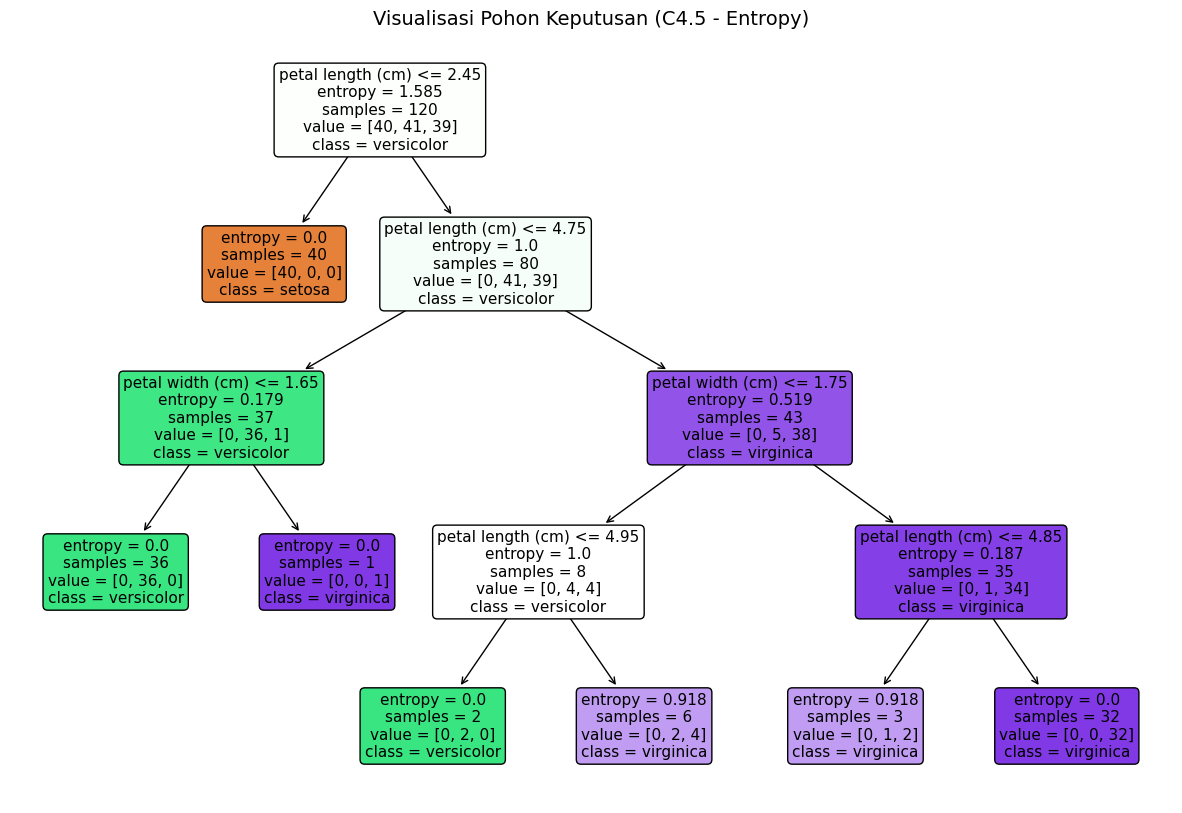

In [7]:
plt.figure(figsize=(15, 10))
plot_tree(
    model_c45, 
    feature_names=iris.feature_names, 
    class_names=list(iris.target_names), 
    filled=True, 
    rounded=True,
    fontsize=11
)
plt.title("Visualisasi Pohon Keputusan (C4.5 - Entropy)", fontsize=14)
plt.show()